In [1]:
# Cell 1: Load, format and save GNN predictions as 5 separate fold CSVs

import pandas as pd
from pathlib import Path

# ── Paths — update these ──────────────────────────────────────────────────────
GNN_ROOT   = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\GNN\prediction")   # folder containing fold_0, fold_1 etc
EXPORT_DIR = Path(r"E:\Optiver\GNN_pred")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
# ─────────────────────────────────────────────────────────────────────────────

for fold_idx in range(5):
    fold_path = GNN_ROOT / f"fold_{fold_idx}" / "gnn_predictions.csv"
    
    if not fold_path.exists():
        print(f"WARNING: {fold_path} not found — skipping")
        continue
    
    df = pd.read_csv(fold_path)
    
    # Keep only needed columns, rename to standard format, add fold
    df = df[["stock_id", "time_id", "true_rv", "pred_rv"]]\
          .rename(columns={
              "true_rv": "actual_rv",
              "pred_rv": "predicted_rv",
          })
    df.insert(2, "fold", fold_idx)
    df = df.sort_values(["stock_id", "time_id"]).reset_index(drop=True)
    
    out_path = EXPORT_DIR / f"gnn_fold_{fold_idx}_predictions.csv"
    df.to_csv(out_path, index=False)
    
    print(f"Fold {fold_idx}: {len(df):,} rows saved to {out_path.name}")
    print(df.head(3))
    print()

print("Cell 1 complete — GNN predictions saved to", EXPORT_DIR)

Fold 0: 85,786 rows saved to gnn_fold_0_predictions.csv
   stock_id  time_id  fold  actual_rv  predicted_rv
0         0        5     0   0.001467      0.001703
1         0      147     0   0.001014      0.001177
2         0      157     0   0.002212      0.002755

Fold 1: 85,790 rows saved to gnn_fold_1_predictions.csv
   stock_id  time_id  fold  actual_rv  predicted_rv
0         0       62     1   0.001154      0.000618
1         0      213     1   0.001287      0.001214
2         0      229     1   0.000183      0.000408

Fold 2: 85,789 rows saved to gnn_fold_2_predictions.csv
   stock_id  time_id  fold  actual_rv  predicted_rv
0         0       11     2   0.000896      0.000348
1         0       31     2   0.000987      0.000583
2         0       62     2   0.001154      0.000622

Fold 3: 85,787 rows saved to gnn_fold_3_predictions.csv
   stock_id  time_id  fold  actual_rv  predicted_rv
0         0       62     3   0.001154      0.000614
1         0      169     3   0.000721      0.

In [2]:
# Cell 2: Format GARCH predictions in place — add fold column, rename columns

import pandas as pd
from pathlib import Path

# ── Path — update this ────────────────────────────────────────────────────────
GARCH_DIR = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\GARCH PREDICTIONS")
# ─────────────────────────────────────────────────────────────────────────────

for fold_idx in range(5):
    file_path = GARCH_DIR / f"garch_predictions_fold{fold_idx}.csv"
    
    if not file_path.exists():
        print(f"WARNING: {file_path} not found — skipping")
        continue
    
    df = pd.read_csv(file_path)
    
    df = df.rename(columns={
        "true_rv": "actual_rv",
        "pred_rv": "predicted_rv",
    })
    df.insert(2, "fold", fold_idx)
    df = df.sort_values(["stock_id", "time_id"]).reset_index(drop=True)
    
    df.to_csv(file_path, index=False)
    
    print(f"Fold {fold_idx}: {len(df):,} rows updated in {file_path.name}")
    print(df.head(3))
    print()

print("Cell 2 complete — GARCH predictions updated in place")

Fold 0: 85,717 rows updated in garch_predictions_fold0.csv
  stock_id  time_id  fold  actual_rv  predicted_rv
0  stock_0        5     0   0.001467      0.002125
1  stock_0      147     0   0.001014      0.001311
2  stock_0      157     0   0.002212      0.003520

Fold 1: 85,700 rows updated in garch_predictions_fold1.csv
  stock_id  time_id  fold  actual_rv  predicted_rv
0  stock_0       62     1   0.001154      0.000808
1  stock_0      213     1   0.001287      0.001443
2  stock_0      229     1   0.000182      0.000481

Fold 2: 85,705 rows updated in garch_predictions_fold2.csv
  stock_id  time_id  fold  actual_rv  predicted_rv
0  stock_0       11     2   0.000896      0.000406
1  stock_0       31     2   0.000987      0.001025
2  stock_0       62     2   0.001154      0.000808

Fold 3: 85,709 rows updated in garch_predictions_fold3.csv
  stock_id  time_id  fold  actual_rv  predicted_rv
0  stock_0       62     3   0.001154      0.000808
1  stock_0      169     3   0.000721      0.001

In [4]:
# Cell 2b: Fix GARCH stock_id format — strip 'stock_' prefix and convert to integer

import pandas as pd
from pathlib import Path

# ── Path ──────────────────────────────────────────────────────────────────────
GARCH_DIR = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\GARCH PREDICTIONS")
# ─────────────────────────────────────────────────────────────────────────────

for fold_idx in range(5):
    file_path = GARCH_DIR / f"garch_predictions_fold{fold_idx}.csv"

    if not file_path.exists():
        print(f"WARNING: {file_path} not found — skipping")
        continue

    df = pd.read_csv(file_path)

    df["stock_id"] = df["stock_id"].astype(str)\
                                   .str.replace("stock_", "", regex=False)\
                                   .astype(int)

    df.to_csv(file_path, index=False)

    print(f"Fold {fold_idx}: stock_id fixed — sample: {df['stock_id'].head(3).tolist()}")

print("\nCell 2b complete — GARCH stock_id converted to integer")

Fold 0: stock_id fixed — sample: [0, 0, 0]
Fold 1: stock_id fixed — sample: [0, 0, 0]
Fold 2: stock_id fixed — sample: [0, 0, 0]
Fold 3: stock_id fixed — sample: [0, 0, 0]
Fold 4: stock_id fixed — sample: [0, 0, 0]

Cell 2b complete — GARCH stock_id converted to integer


In [9]:
# Cell 3: Diebold-Mariano tests across all models
# Models: Base HAR, QLIKE-LGB, GNN, GARCH
# Tests both RMSPE and QLIKE pairwise combinations

import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path
import itertools

# ── Paths — update these ──────────────────────────────────────────────────────
HAR_DIR   = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\BASE-HAR")
QLIKE_DIR = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\HAR+LightGBM(QLIKE)")
GNN_DIR   = Path(r"E:\Optiver\GNN_pred")
GARCH_DIR = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\GARCH PREDICTIONS")
EVAL_DIR  = Path(r"E:\Optiver\outputs\evaluation")
EVAL_DIR.mkdir(parents=True, exist_ok=True)
EPS       = 1e-10
# ─────────────────────────────────────────────────────────────────────────────

# ── Load all models across 5 folds ───────────────────────────────────────────
def load_model_folds(fold_dir, filename_fn):
    """Load 5 fold CSVs and concatenate into one dataframe."""
    frames = []
    for fold_idx in range(5):
        path = fold_dir / filename_fn(fold_idx)
        if not path.exists():
            print(f"WARNING: {path} not found — skipping")
            continue
        frames.append(pd.read_csv(path))
    df = pd.concat(frames, ignore_index=True)
    df["stock_id"] = df["stock_id"].astype(int)
    df["time_id"]  = df["time_id"].astype(int)
    df["fold"]     = df["fold"].astype(int)
    return df

print("Loading all models...")
har_df   = load_model_folds(HAR_DIR,   lambda f: f"base_har_fold{f}_predictions.csv")
qlike_df = load_model_folds(QLIKE_DIR, lambda f: f"qlike_lgb_fold{f}_predictions.csv")
gnn_df   = load_model_folds(GNN_DIR,   lambda f: f"gnn_fold_{f}_predictions.csv")
garch_df = load_model_folds(GARCH_DIR, lambda f: f"garch_predictions_fold{f}.csv")

for name, df in [("HAR", har_df), ("QLIKE-LGB", qlike_df),
                 ("GNN", gnn_df), ("GARCH", garch_df)]:
    print(f"  {name:<12} {len(df):,} rows  |  folds: {sorted(df['fold'].unique())}")

# ── Align on common stock_id + time_id + fold ─────────────────────────────────
print("\nAligning all models...")
base = har_df[["stock_id", "time_id", "fold", "actual_rv"]].copy()

for name, df in [("HAR", har_df), ("QLIKE-LGB", qlike_df),
                 ("GNN", gnn_df), ("GARCH", garch_df)]:
    base = base.merge(
        df[["stock_id", "time_id", "fold", "predicted_rv"]].rename(
            columns={"predicted_rv": f"pred_{name}"}
        ),
        on=["stock_id", "time_id", "fold"],
        how="inner",
    )

print(f"Aligned rows: {len(base):,}")

# ── Verify actual_rv consistency ──────────────────────────────────────────────
print("\nActual RV consistency check:")
for name, df in [("QLIKE-LGB", qlike_df), ("GNN", gnn_df), ("GARCH", garch_df)]:
    merged   = base.merge(
        df[["stock_id", "time_id", "fold", "actual_rv"]].rename(
            columns={"actual_rv": f"actual_{name}"}
        ),
        on=["stock_id", "time_id", "fold"],
        how="inner",
    )
    max_diff = (merged["actual_rv"] - merged[f"actual_{name}"]).abs().max()
    status   = "OK" if max_diff < 1e-6 else "WARNING — possible mismatch"
    print(f"  {name:<12} max diff: {max_diff:.2e}  {status}")

actual      = base["actual_rv"].values
model_names = ["HAR", "QLIKE-LGB", "GNN", "GARCH"]

# ── Loss functions ────────────────────────────────────────────────────────────
def rmspe_loss(y_true, y_pred):
    y_true = np.maximum(y_true, EPS)
    y_pred = np.maximum(y_pred, EPS)
    return ((y_true - y_pred) / y_true)**2

def qlike_loss(y_true, y_pred):
    y_true = np.maximum(y_true, EPS)
    y_pred = np.maximum(y_pred, EPS)
    return y_true / y_pred - np.log(y_true / y_pred) - 1

# ── Newey-West HAC variance ───────────────────────────────────────────────────
def newey_west_var(d, h):
    n      = len(d)
    gamma0 = np.var(d, ddof=1)
    gamma  = sum(
        [(1 - k / (h + 1)) * np.cov(d[k:], d[:-k])[0, 1]
         for k in range(1, h + 1)]
    )
    return (gamma0 + 2 * gamma) / n

# ── DM test ───────────────────────────────────────────────────────────────────
def diebold_mariano(y_true, pred1, pred2, loss_fn):
    """Positive DM stat = model 2 significantly better than model 1."""
    d       = loss_fn(y_true, pred1) - loss_fn(y_true, pred2)
    n       = len(d)
    h       = int(n**(1/3))
    var_d   = newey_west_var(d, h)
    dm_stat = d.mean() / np.sqrt(max(var_d, EPS))
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return float(dm_stat), float(p_value)

def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

# ── Pooled metrics ────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"Pooled OOF Metrics — All Models")
print(f"{'='*60}")
print(f"  {'Model':<12} {'RMSPE':>10} {'QLIKE':>10}")
print(f"  {'='*35}")
for name in model_names:
    pred = base[f"pred_{name}"].values
    r    = float(np.sqrt(np.mean(rmspe_loss(actual, pred))))
    q    = float(np.mean(qlike_loss(actual, pred)))
    print(f"  {name:<12} {r:>10.6f} {q:>10.6f}")

# ── DM tests ──────────────────────────────────────────────────────────────────
results = []
for metric_name, loss_fn in [("RMSPE", rmspe_loss), ("QLIKE", qlike_loss)]:
    print(f"\n{'='*65}")
    print(f"Diebold-Mariano Tests — {metric_name}")
    print(f"Positive DM stat = model 2 significantly better")
    print(f"{'='*65}")
    print(f"  {'Model 1':<12} {'Model 2':<12} {'DM Stat':>10} {'p-value':>10} {'Sig':>5}")
    print(f"  {'-'*52}")

    for m1, m2 in itertools.combinations(model_names, 2):
        pred1  = base[f"pred_{m1}"].values
        pred2  = base[f"pred_{m2}"].values
        dm, p  = diebold_mariano(actual, pred1, pred2, loss_fn)
        sig    = sig_stars(p)
        print(f"  {m1:<12} {m2:<12} {dm:>10.4f} {p:>10.4f} {sig:>5}")
        results.append({
            "metric":  metric_name,
            "model_1": m1,
            "model_2": m2,
            "dm_stat": dm,
            "p_value": p,
            "sig":     sig,
        })


# ── Per fold RMSPE breakdown + store fold metrics ─────────────────
print(f"\n{'='*65}")
print(f"Per-fold RMSPE breakdown")
print(f"{'='*65}")
print(f"  {'Fold':<6}", end="")
for name in model_names:
    print(f" {name:>12}", end="")
print()

fold_qlike_metrics = {name: [] for name in model_names}
fold_rmspe_metrics = {name: [] for name in model_names}

for f in range(5):
    mask = base["fold"].values == f
    print(f"  {f:<6}", end="")
    for name in model_names:
        pred = base[f"pred_{name}"].values
        r    = float(np.sqrt(np.mean(rmspe_loss(actual[mask], pred[mask]))))
        q    = float(np.mean(qlike_loss(actual[mask], pred[mask])))
        fold_rmspe_metrics[name].append(r)
        fold_qlike_metrics[name].append(q)
        print(f" {r:>12.6f}", end="")
    print()

print(f"\n{'='*65}")
print(f"Per-fold QLIKE breakdown (reproduced for reference)")
print(f"{'='*65}")
print(f"  {'Fold':<6}", end="")
for name in model_names:
    print(f" {name:>12}", end="")
print()
for f in range(5):
    print(f"  {f:<6}", end="")
    for name in model_names:
        print(f" {fold_qlike_metrics[name][f]:>12.6f}", end="")
    print()

print(f"\nFold metrics stored as fold_qlike_metrics and fold_rmspe_metrics for Cell 5")

# ── Save ──────────────────────────────────────────────────────────────────────
dm_df = pd.DataFrame(results)
dm_df.to_csv(EVAL_DIR / "dm_tests_all_models.csv", index=False)
print(f"\nSaved: {EVAL_DIR / 'dm_tests_all_models.csv'}")
print("Cell 3 complete")

Loading all models...
  HAR          428,932 rows  |  folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  QLIKE-LGB    428,932 rows  |  folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  GNN          428,932 rows  |  folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  GARCH        428,513 rows  |  folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Aligning all models...
Aligned rows: 428,513

Actual RV consistency check:
  QLIKE-LGB    max diff: 0.00e+00  OK
  GNN          max diff: 7.87e-03  WARNING — possible mismatch
  GARCH        max diff: 7.87e-03  WARNING — possible mismatch

Pooled OOF Metrics — All Models
  Model             RMSPE      QLIKE
  HAR            0.451700   0.050243
  QLIKE-LGB      0.462851   0.044344
  GNN            0.366462   0.071431
  GARCH          0.693840   0.055918

Diebold-Mariano Tests — RMSPE
Positive DM stat = model 2 significantly better
  Model 1      Model 

In [7]:
# Cell CHECK: Validate row counts across all original prediction files

import pandas as pd
from pathlib import Path

# ── Paths — original files ────────────────────────────────────────────────────
HAR_DIR   = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\BASE-HAR")
QLIKE_DIR = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\HAR+LightGBM(QLIKE)")
GNN_ROOT  = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\GNN\prediction")     # folder containing fold_0, fold_1 etc
GARCH_DIR = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\GARCH PREDICTIONS")
EPS       = 1e-10
# ─────────────────────────────────────────────────────────────────────────────

print(f"{'='*60}")
print(f"Row count validation — original prediction files")
print(f"{'='*60}")

# HAR
print(f"\nHAR:")
har_total = 0
for fold_idx in range(5):
    path  = HAR_DIR / f"base_har_fold{fold_idx}_predictions.csv"
    n     = len(pd.read_csv(path))
    har_total += n
    print(f"  fold_{fold_idx}: {n:,} rows")
print(f"  Total: {har_total:,}")

# QLIKE-LGB
print(f"\nQLIKE-LGB:")
qlike_total = 0
for fold_idx in range(5):
    path  = QLIKE_DIR / f"qlike_lgb_fold{fold_idx}_predictions.csv"
    n     = len(pd.read_csv(path))
    qlike_total += n
    print(f"  fold_{fold_idx}: {n:,} rows")
print(f"  Total: {qlike_total:,}")

# GNN — reads from original fold folders
print(f"\nGNN:")
gnn_total = 0
for fold_idx in range(5):
    path  = GNN_ROOT / f"fold_{fold_idx}" / "gnn_predictions.csv"
    n     = len(pd.read_csv(path))
    gnn_total += n
    print(f"  fold_{fold_idx}: {n:,} rows")
print(f"  Total: {gnn_total:,}")

# GARCH
print(f"\nGARCH:")
garch_total = 0
for fold_idx in range(5):
    path  = GARCH_DIR / f"garch_predictions_fold{fold_idx}.csv"
    n     = len(pd.read_csv(path))
    garch_total += n
    print(f"  fold_{fold_idx}: {n:,} rows")
print(f"  Total: {garch_total:,}")

# Summary
print(f"\n{'='*60}")
print(f"Summary")
print(f"{'='*60}")
print(f"  {'Model':<12} {'Total rows':>12} {'vs HAR':>10}")
print(f"  {'='*36}")
for name, total in [("HAR", har_total), ("QLIKE-LGB", qlike_total),
                    ("GNN", gnn_total), ("GARCH", garch_total)]:
    diff = total - har_total
    print(f"  {name:<12} {total:>12,} {diff:>+10,}")

print(f"\nCell 4 complete")

Row count validation — original prediction files

HAR:
  fold_0: 85,786 rows
  fold_1: 85,790 rows
  fold_2: 85,789 rows
  fold_3: 85,787 rows
  fold_4: 85,780 rows
  Total: 428,932

QLIKE-LGB:
  fold_0: 85,786 rows
  fold_1: 85,790 rows
  fold_2: 85,789 rows
  fold_3: 85,787 rows
  fold_4: 85,780 rows
  Total: 428,932

GNN:
  fold_0: 85,786 rows
  fold_1: 85,790 rows
  fold_2: 85,789 rows
  fold_3: 85,787 rows
  fold_4: 85,780 rows
  Total: 428,932

GARCH:
  fold_0: 85,717 rows
  fold_1: 85,700 rows
  fold_2: 85,705 rows
  fold_3: 85,709 rows
  fold_4: 85,682 rows
  Total: 428,513

Summary
  Model          Total rows     vs HAR
  HAR               428,932         +0
  QLIKE-LGB         428,932         +0
  GNN               428,932         +0
  GARCH             428,513       -419

Cell 4 complete


In [10]:
# Cell 4: Multiple testing correction — Benjamini-Hochberg FDR
from statsmodels.stats.multitest import multipletests
import pandas as pd
from pathlib import Path

EVAL_DIR = Path(r"E:\Optiver\outputs\evaluation")

dm_df = pd.read_csv(EVAL_DIR / "dm_tests_all_models.csv")

print(f"{'='*75}")
print(f"Multiple Testing Correction — Benjamini-Hochberg FDR")
print(f"{'='*75}")
print(f"  {'Metric':<8} {'Model 1':<12} {'Model 2':<12} {'DM Stat':>10} {'p-value':>10} {'p-corrected':>12} {'Sig':>5}")
print(f"  {'-'*70}")

for metric in ["RMSPE", "QLIKE"]:
    mask               = dm_df["metric"] == metric
    pvals              = dm_df.loc[mask, "p_value"].values
    rejected, pvals_corrected, _, _ = multipletests(pvals, method="fdr_bh")
    dm_df.loc[mask, "p_value_corrected"] = pvals_corrected
    dm_df.loc[mask, "rejected_corrected"] = rejected

    for _, row in dm_df[mask].iterrows():
        sig = "***" if row["p_value_corrected"] < 0.001 else \
              "**"  if row["p_value_corrected"] < 0.01  else \
              "*"   if row["p_value_corrected"] < 0.05  else ""
        print(f"  {metric:<8} {row['model_1']:<12} {row['model_2']:<12} "
              f"{row['dm_stat']:>10.4f} {row['p_value']:>10.4f} "
              f"{row['p_value_corrected']:>12.6f} {sig:>5}")

dm_df.to_csv(EVAL_DIR / "dm_tests_all_models_corrected.csv", index=False)
print(f"\nSaved: {EVAL_DIR / 'dm_tests_all_models_corrected.csv'}")
print("Cell 4 complete")

Multiple Testing Correction — Benjamini-Hochberg FDR
  Metric   Model 1      Model 2         DM Stat    p-value  p-corrected   Sig
  ----------------------------------------------------------------------
  RMSPE    HAR          QLIKE-LGB       -3.6826     0.0002     0.000231   ***
  RMSPE    HAR          GNN             14.4108     0.0000     0.000000   ***
  RMSPE    HAR          GARCH          -12.9684     0.0000     0.000000   ***
  RMSPE    QLIKE-LGB    GNN             23.9312     0.0000     0.000000   ***
  RMSPE    QLIKE-LGB    GARCH          -11.8381     0.0000     0.000000   ***
  RMSPE    GNN          GARCH          -14.2801     0.0000     0.000000   ***
  QLIKE    HAR          QLIKE-LGB       48.0204     0.0000     0.000000   ***
  QLIKE    HAR          GNN            -36.9897     0.0000     0.000000   ***
  QLIKE    HAR          GARCH          -46.3150     0.0000     0.000000   ***
  QLIKE    QLIKE-LGB    GNN            -42.0941     0.0000     0.000000   ***
  QLIKE    QLIKE

95% Confidence Intervals — QLIKE
  Model              Mean     CI Lower     CI Upper
  HAR            0.050243     0.049424     0.051062
  QLIKE-LGB      0.044344     0.043612     0.045077
  GNN            0.071430     0.069651     0.073209
  GARCH          0.055918     0.055157     0.056680

95% Confidence Intervals — RMSPE
  Model              Mean     CI Lower     CI Upper
  HAR            0.451490     0.432297     0.470682
  QLIKE-LGB      0.462755     0.449595     0.475915
  GNN            0.366353     0.353930     0.378776
  GARCH          0.693596     0.668013     0.719179


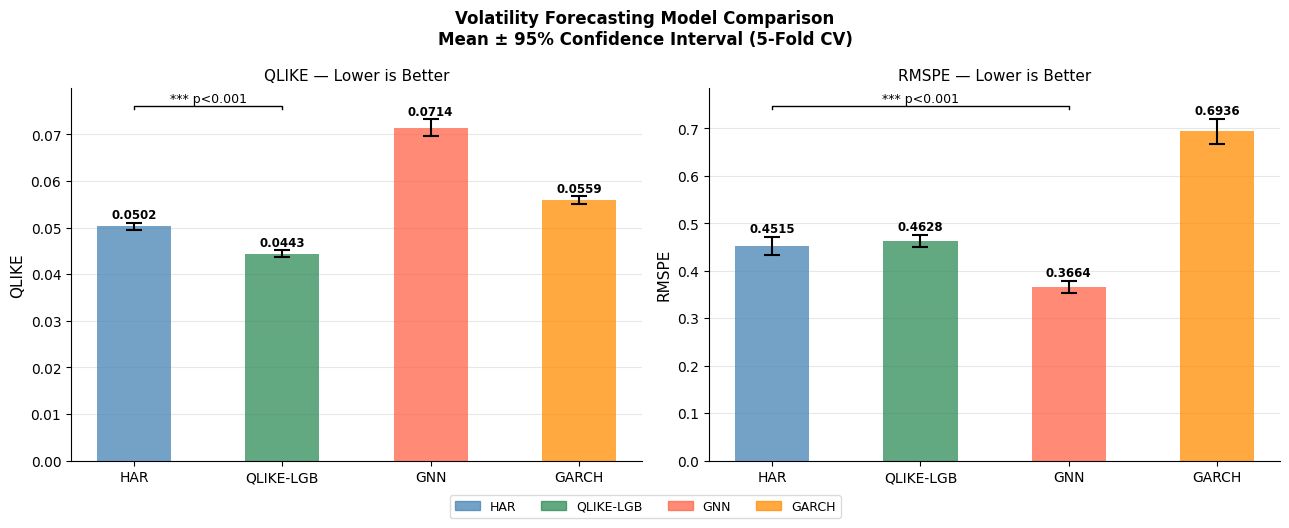


Saved: E:\Optiver\outputs\evaluation\model_comparison_ci.png
Cell 5 complete


In [11]:
# Cell 5: Confidence intervals + error bar plot
# Reads fold_qlike_metrics and fold_rmspe_metrics from Cell 3

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from pathlib import Path

EVAL_DIR    = Path(r"E:\Optiver\outputs\evaluation")
colors      = ["steelblue", "seagreen", "tomato", "darkorange"]

# ── CI computation ────────────────────────────────────────────────────────────
def compute_ci(fold_values, confidence=0.95):
    arr  = np.array(fold_values)
    mean = arr.mean()
    se   = stats.sem(arr)
    ci   = stats.t.interval(confidence, df=len(arr)-1, loc=mean, scale=se)
    return mean, ci[0], ci[1]

print(f"{'='*60}")
print(f"95% Confidence Intervals — QLIKE")
print(f"{'='*60}")
print(f"  {'Model':<12} {'Mean':>10} {'CI Lower':>12} {'CI Upper':>12}")
print(f"  {'='*48}")
for name in model_names:
    mean, lo, hi = compute_ci(fold_qlike_metrics[name])
    print(f"  {name:<12} {mean:>10.6f} {lo:>12.6f} {hi:>12.6f}")

print(f"\n{'='*60}")
print(f"95% Confidence Intervals — RMSPE")
print(f"{'='*60}")
print(f"  {'Model':<12} {'Mean':>10} {'CI Lower':>12} {'CI Upper':>12}")
print(f"  {'='*48}")
for name in model_names:
    mean, lo, hi = compute_ci(fold_rmspe_metrics[name])
    print(f"  {name:<12} {mean:>10.6f} {lo:>12.6f} {hi:>12.6f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Volatility Forecasting Model Comparison\nMean ± 95% Confidence Interval (5-Fold CV)",
    fontsize=12, fontweight="bold"
)

for ax, (metric_name, fold_data) in zip(axes, [
    ("QLIKE",  fold_qlike_metrics),
    ("RMSPE",  fold_rmspe_metrics),
]):
    means, lowers, uppers = [], [], []
    for name in model_names:
        mean, lo, hi = compute_ci(fold_data[name])
        means.append(mean)
        lowers.append(mean - lo)
        uppers.append(hi - mean)

    x    = np.arange(len(model_names))
    bars = ax.bar(x, means, color=colors, alpha=0.75, width=0.5, zorder=2)
    ax.errorbar(x, means,
                yerr=[lowers, uppers],
                fmt="none",
                color="black",
                capsize=6,
                capthick=1.5,
                linewidth=1.5,
                zorder=3)

    # Annotate mean on each bar
    for i, (mean, up) in enumerate(zip(means, uppers)):
        ax.text(i, mean + up + (max(means) * 0.005),
                f"{mean:.4f}",
                ha="center", va="bottom",
                fontsize=8.5, fontweight="bold")

    # Significance bracket — best vs HAR
    best_idx  = int(np.argmin(means))
    har_idx   = model_names.index("HAR")
    if best_idx != har_idx:
        y_bracket = max(m + u for m, u in zip(means, uppers)) + max(means) * 0.03
        x1, x2    = sorted([har_idx, best_idx])
        ax.plot([x1, x1, x2, x2],
                [y_bracket, y_bracket + max(means)*0.01,
                 y_bracket + max(means)*0.01, y_bracket],
                color="black", linewidth=1)
        ax.text((x1 + x2) / 2, y_bracket + max(means) * 0.012,
                "*** p<0.001", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=10)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(f"{metric_name} — Lower is Better", fontsize=11)
    ax.grid(axis="y", alpha=0.3, zorder=1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(bottom=0)

# Legend
patches = [mpatches.Patch(color=c, alpha=0.75, label=n)
           for c, n in zip(colors, model_names)]
fig.legend(handles=patches, loc="lower center", ncol=4,
           fontsize=9, framealpha=0.7,
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
out_path = EVAL_DIR / "model_comparison_ci.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: {out_path}")
print("Cell 5 complete")